<a href="https://colab.research.google.com/github/nathaliaacouto/ADES_Wine_Quality/blob/main/%5BADES%5D_Wine_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Data Analysis and Machine Learning

This notebook presents a complete data analysis pipeline for the **WineQT** dataset.  
The main objective is to analyse the physicochemical properties of wine and predict its quality using machine learning techniques.

## Goals
- Understand the structure and quality of the dataset
- Perform preprocessing and exploratory data analysis
- Identify relevant patterns and correlations
- Apply supervised and unsupervised machine learning algorithms
- Interpret the main findings

## 1. Install and import required libraries

In [27]:
%pip install pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\acaro\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [28]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the dataset
Make sure the file `WineQT.csv` is in the same folder as this notebook.

In [29]:
df = pd.read_csv('WineQT.csv')

In [30]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 3. Initial dataset inspection
We start by checking the shape, column names, data types, and a quick statistical summary.

In [31]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (1143, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


## 4. Problem statement

The objective of this project is to analyse the physicochemical properties of wine and understand how they influence its quality.

Additionally, we aim to develop machine learning models capable of predicting wine quality based on these features.

## 5. Data quality checks

### 5.1 Missing values
We first check whether the dataset contains null values.

In [34]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


**Interpretation:**  
The dataset does not contain missing values, so no imputation is required.

### 5.2 Duplicate rows
It is also useful to verify if duplicate observations exist.

In [35]:
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


## 6. Exploratory Data Analysis

### 6.1 Target variable distribution
Understanding the distribution of the target variable is important before training models.

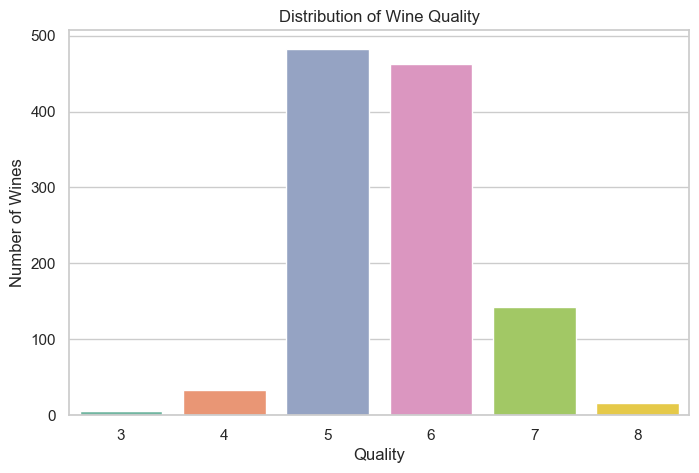

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, hue="quality", palette="Set2", legend=False)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")
plt.show()

In [37]:
quality_distribution = df["quality"].value_counts().sort_index()
quality_distribution

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [38]:
quality_distribution_normalized = df["quality"].value_counts(normalize=True).sort_index() * 100
quality_distribution_normalized.round(2)

quality
3     0.52
4     2.89
5    42.26
6    40.42
7    12.51
8     1.40
Name: proportion, dtype: float64

**Interpretation:**  
The target variable is not perfectly balanced. Most wines are concentrated around quality levels **5** and **6**, while extreme quality values are less frequent. This imbalance should be considered during modelling and interpretation.

### 6.2 Correlation heatmap
A correlation matrix helps identify linear relationships between features and with the target variable.

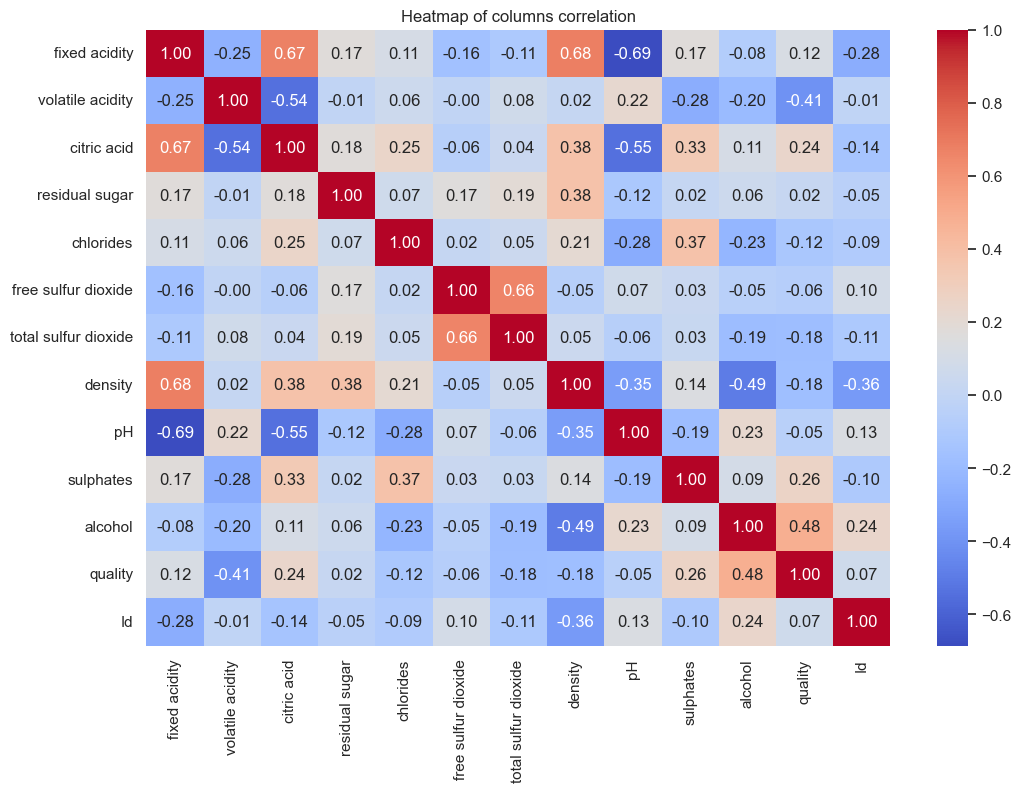

In [39]:
correlation = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of columns correlation')
plt.show()

**Interpretation:**  
This heatmap helps identify features that may be positively or negatively associated with wine quality.  
In this dataset, variables such as **alcohol** usually show a positive association with quality, while **volatile acidity** tends to show a negative one.

### 6.3 Boxplots by quality
Boxplots are useful for visualising distributions and potential outliers for each feature across quality levels.

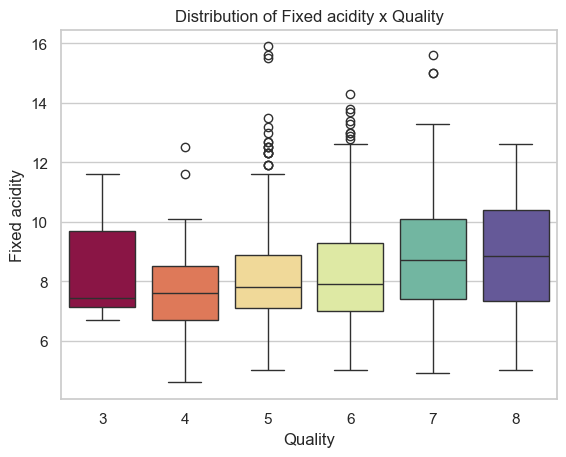

In [40]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='fixed acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Fixed acidity x Quality')
plt.ylabel('Fixed acidity')
plt.xlabel('Quality')
plt.show()

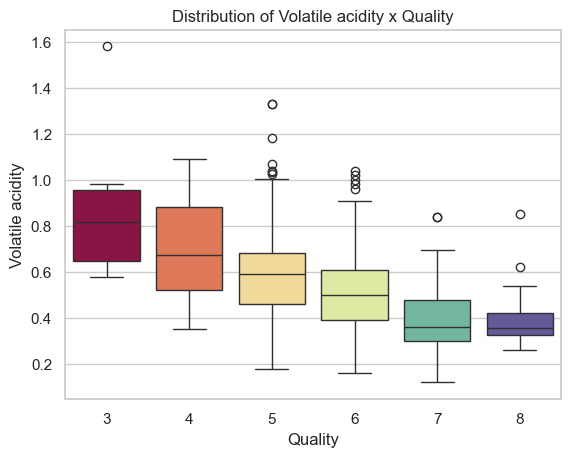

In [41]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='volatile acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Volatile acidity x Quality')
plt.ylabel('Volatile acidity')
plt.xlabel('Quality')
plt.show()

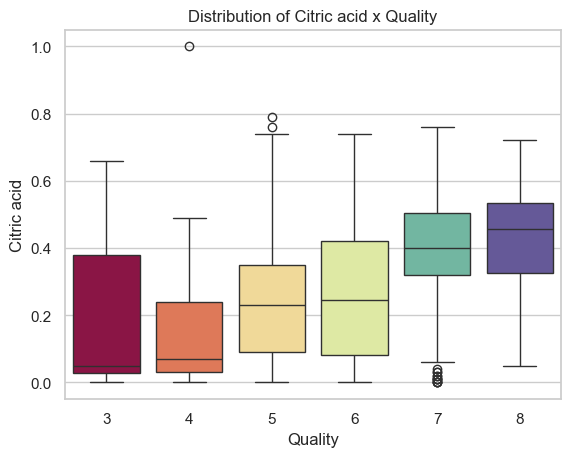

In [42]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='citric acid', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Citric acid x Quality')
plt.ylabel('Citric acid')
plt.xlabel('Quality')
plt.show()

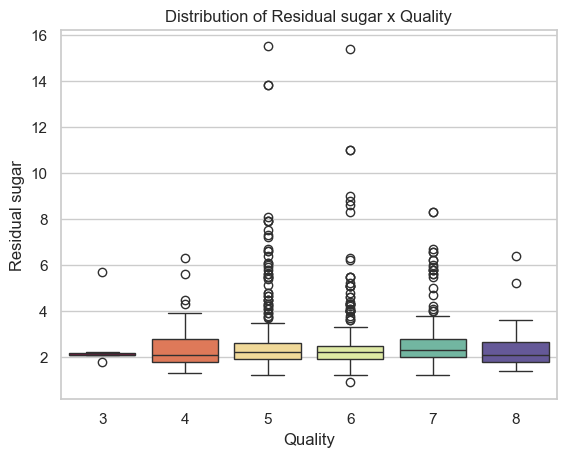

In [43]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='residual sugar', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Residual sugar x Quality')
plt.ylabel('Residual sugar')
plt.xlabel('Quality')
plt.show()

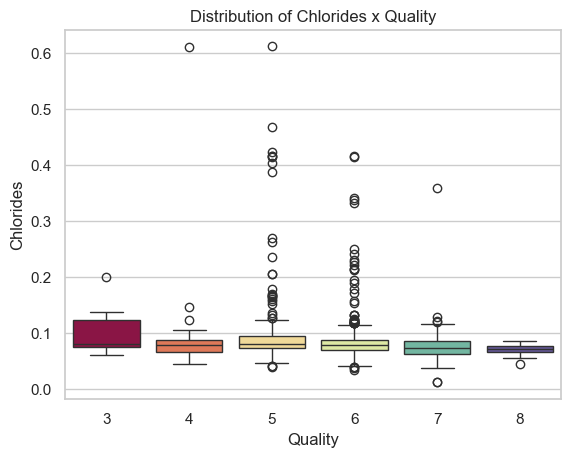

In [44]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='chlorides', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Chlorides x Quality')
plt.ylabel('Chlorides')
plt.xlabel('Quality')
plt.show()

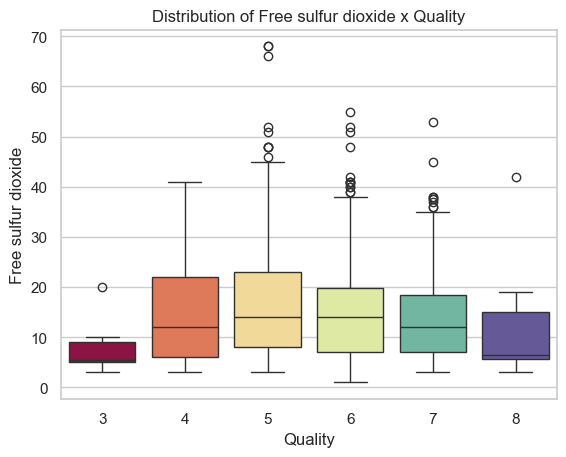

In [45]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='free sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Free sulfur dioxide x Quality')
plt.ylabel('Free sulfur dioxide')
plt.xlabel('Quality')
plt.show()

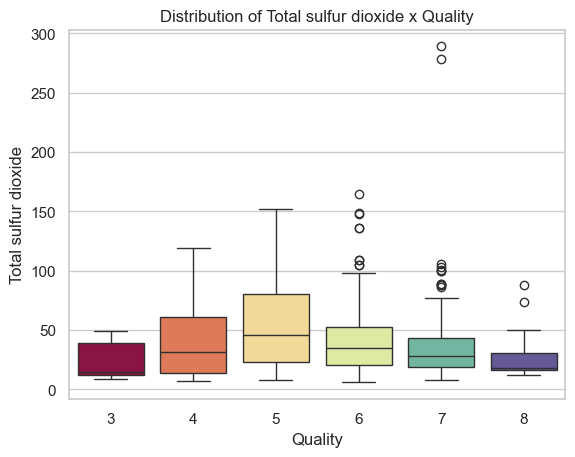

In [46]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='total sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Total sulfur dioxide x Quality')
plt.ylabel('Total sulfur dioxide')
plt.xlabel('Quality')
plt.show()

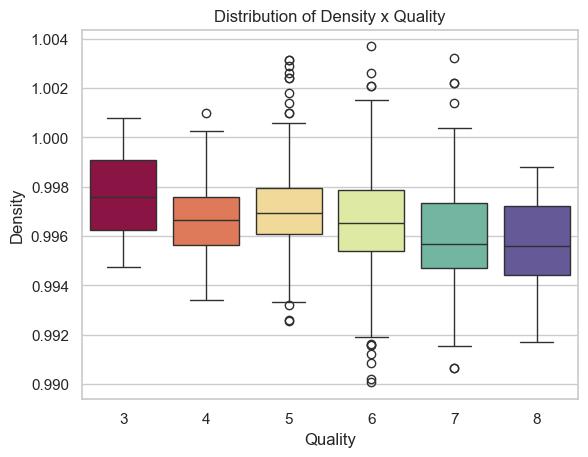

In [47]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='density', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Density x Quality')
plt.ylabel('Density')
plt.xlabel('Quality')
plt.show()

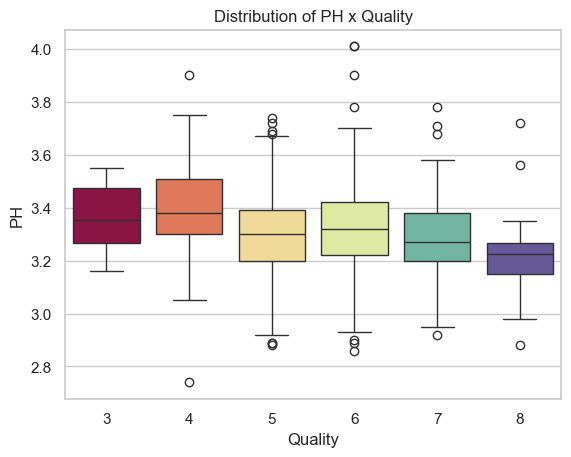

In [48]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='pH', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of PH x Quality')
plt.ylabel('PH')
plt.xlabel('Quality')
plt.show()

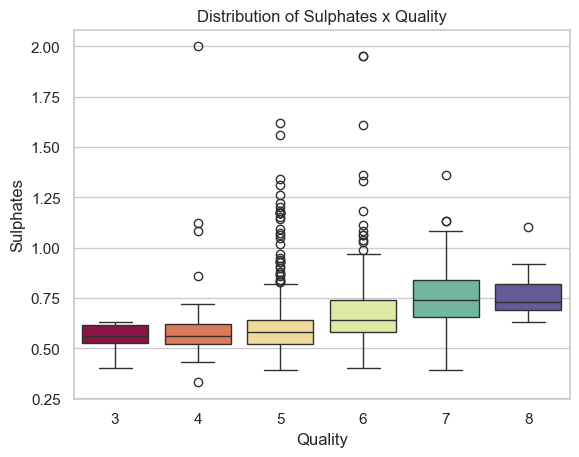

In [49]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='sulphates', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Sulphates x Quality')
plt.ylabel('Sulphates')
plt.xlabel('Quality')
plt.show()

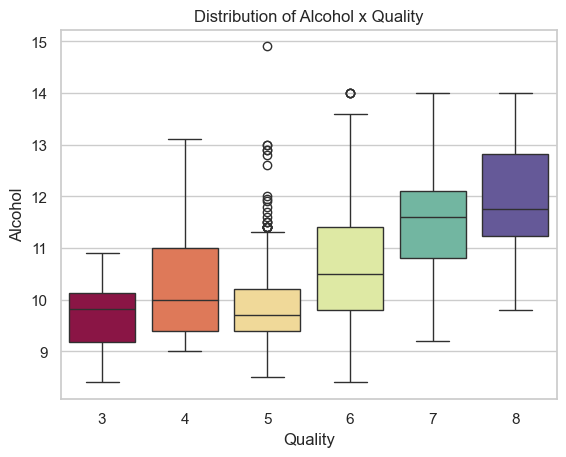

In [50]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='alcohol', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Alcohol x Quality')
plt.ylabel('Alcohol')
plt.xlabel('Quality')
plt.show()

### 6.4 Histograms of the main variables
Histograms help us inspect the distribution of each numeric feature.

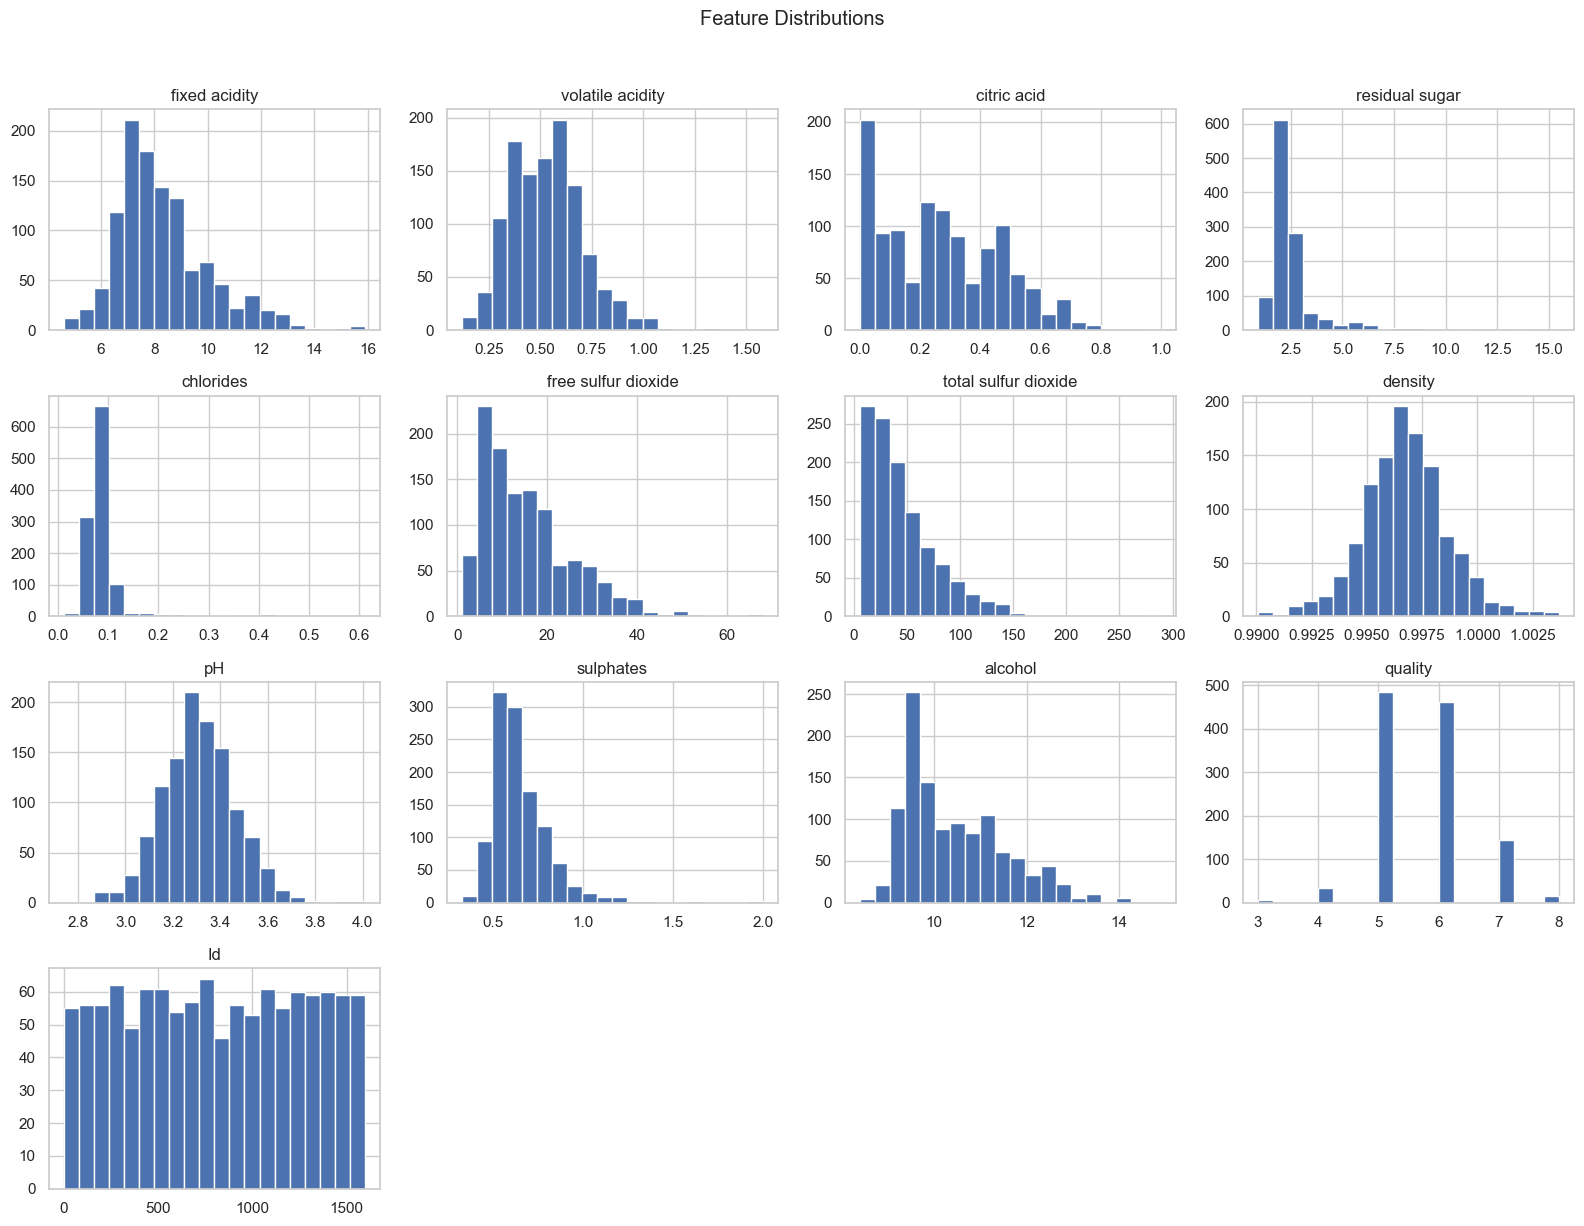

In [51]:
df.hist(figsize=(16, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## 7. Preprocessing

### 7.1 Remove the `Id` column
Before moving forward with outlier removal and modeling, we need to drop the 'Id' column. This variable serves only as a unique index for each row and holds no real-world predictive value regarding the wine's quality. As we saw in the correlation heatmap, keeping random identifiers can introduce noise and cause our algorithms to find false mathematical relationships that don't actually exist.

In [52]:
df.drop('Id', axis=1, inplace=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
